<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/softmax_binomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* Este notebook presenta un estudio detallado del rendimiento del algoritmo **Softmax** en un problema de k-armed bandit.

Se comparan diferentes configuraciones del parámetro de temperatura $\tau$ (tau) para analizar el compromiso entre exploración y explotación en el contexto de la distribución de recompensa **Binomial**.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/28

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

## Preparación del entorno

Importamos las librerías necesarias y copiamos nuestro repositorio del proyecto.

In [1]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git

Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 632, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 632 (delta 157), reused 164 (delta 77), pack-reused 351 (from 1)
Receiving objects: 100% (632/632), 34.47 MiB | 17.05 MiB/s, done.
Resolving deltas: 100% (354/354), done.


In [2]:
%cd FernandezMartinezPolo-EML-RL/k_brazos

/content/FernandezMartinezPolo-EML-RL/k_brazos


In [3]:
#Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('./src')

# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


## Diseño del experimento

En este notebook se analiza un problema de bandido multi-brazo de 10 brazos, donde cada brazo sigue una distribución Binomial $B(n, p)$ con $n = 10$ ensayos y probabilidad de éxito $p \in (0, 1)$. Se implementan cuatro configuraciones del algoritmo Softmax, utilizando distintos valores del parámetro de temperatura $\tau$.

A diferencia de estrategias como $\varepsilon$-Greedy, donde en cada paso se elige una acción aleatoria con probabilidad $\varepsilon$ y, en caso contrario, se selecciona la acción con mayor recompensa media estimada, el algoritmo Softmax asigna una probabilidad de selección a cada acción de forma proporcional a su valor estimado. En concreto, en cada iteración se selecciona la acción $a$ con probabilidad:

$$
P_t(a) = \frac{e^{Q_t(a) / \tau}}{\sum_{b=1}^k e^{Q_t(b) / \tau}}
$$

donde $Q_t(a)$ representa la estimación actual de la recompensa media de la acción $a$, y $\tau > 0$ es el parámetro de temperatura que controla el equilibrio entre exploración y explotación.

Podemos interpretar el efecto del parámetro $\tau$ sobre el comportamiento del agente de la siguiente manera: con valores altos de $\tau$, las diferencias entre los $Q_t(a)$ se diluyen y la distribución de probabilidad se aproxima a la uniforme, fomentando la exploración. Con valores bajos, las diferencias se amplifican y el algoritmo tiende a seleccionar casi siempre la acción con mayor valor estimado, comportándose de forma similar a una política greedy.

Es importante calibrar el valor de $\tau$ en relación con la escala de las recompensas del entorno, puesto que, como hemos comprobado empíricamente, valores desproporcionadamente pequeños o grandes respecto a las diferencias reales entre brazos producen comportamientos de sobreexplotación o sobreexploración extrema, desvirtuando los experimentos. En el caso de brazos de distribución Binomial con $n = 10$ ensayos, las recompensas toman valores enteros en el rango $[0, 10]$ y el valor esperado de cada brazo es $Q = n \cdot p$. Esto produce diferencias absolutas entre brazos considerablemente mayores que en el caso Bernoulli (donde las recompensas están acotadas en $[0, 1]$), pero del mismo orden de magnitud que en el caso Normal con $\mu \in [1, 10]$. Además, la varianza de cada brazo, dada por $n \cdot p \cdot (1 - p)$, es también mayor que en el caso Bernoulli, lo que introduce más ruido en las estimaciones iniciales.

Por ello, los cuatro valores seleccionados ($\tau = 0.5$, $\tau = 1.0$, $\tau = 2.0$ y $\tau = 5.0$) se han elegido de forma que sean acordes a la escala del entorno Binomial y cubran varios regímenes cualitativamente distintos, desde una política predominantemente explotadora ($\tau = 0.5$) hasta una exploración prácticamente uniforme ($\tau = 5.0$). Nótese que estos valores son del mismo orden que los utilizados en el experimento con distribución Normal, dado que las escalas de recompensa son similares, y muy superiores a los empleados en el caso Bernoulli, donde las diferencias entre brazos eran mucho menores.

El interés de este experimento reside en que el algoritmo no utiliza información sobre el número de veces que se ha seleccionado cada brazo para guiar la exploración, sino que la probabilidad de selección depende únicamente de las estimaciones de valor $Q_t(a)$. Esto lo hace especialmente sensible a la calidad de dichas estimaciones en las primeras iteraciones, cuando aún son ruidosas. En el caso Binomial, esta sensibilidad es relevante porque, aunque la escala de recompensas es mayor que en Bernoulli, la varianza intrínseca de la distribución $B(n, p)$ puede provocar que un brazo con valor esperado alto reciba por azar una recompensa baja en sus primeras selecciones, penalizando su estimación durante varias iteraciones. Estudiar su comportamiento con distintos valores de $\tau$ permite analizar cómo gestiona este algoritmo la incertidumbre inicial y en qué medida logra identificar y explotar el brazo óptimo a lo largo del tiempo.

### Configuración del Experimento
Cada política se evalúa a lo largo de 2000 iteraciones, y todo el experimento se repite 500 veces de forma independiente. En cada iteración se calcula la media de las recompensas obtenidas considerando esas 500 ejecuciones.

La razón por la que se usan 2000 iteraciones, es que se requiere un horizonte temporal suficientemente largo para observar el comportamiento asintótico de los algoritmos y obtener estimaciones estables del rechazo acumulado.

La comparación entre algoritmos se realiza utilizando varias métricas: recompensa media, proporción media de selecciones óptimas, rechazo acumulado medio y ganancia y número de selecciones promedio por brazo.

In [4]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar los rechazos promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms] #Para las arm stats

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        sum_current_run_expected_value = np.zeros(len(algorithms)) # Aquí se almacena el valor esperado acumulado para cada algoritmo de esta run. Necesario para calcular el rechazo

        for idx, algo in enumerate(algorithms):
            for step in range(steps):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward # Actualizar la ganancia del brazo seleccionado por el algoritmo.
                arm_stats[idx]['selections'][chosen_arm] += 1 # Actualizar el número de selecciones del brazo seleccionado por el algoritmo.

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Modificar optimal_selections cuando el brazo elegido se corresponde con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Si el step actual es 0, el valor esperado acumulado se inicializa con el valor esperado del brazo
                # elegido actualmente. Si no, se suma el valor esperado del brazo actual al valor acumulado
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] = sum_current_run_expected_value[idx] + bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step+1)*bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = optimal_selections*100/runs

    for stat in arm_stats:
      stat['mean_rewards'] /= runs
      stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats

Definimos los parámetros del experimento seleccionados en la fase de diseño experimental:

In [5]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 2000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k=k)) # Generar un bandido con k brazos de distribución Binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")


# Algoritmos a comparar (distintas temperaturas, adaptadas a la escala Binomial)
algorithms_binomial = [
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=1.0),
    Softmax(k=k, tau=2.0),
    Softmax(k=k, tau=5.0)
]

# Ejecutar
rewards_bi, regrets_bi, optimal_bi, arm_stats_bi = run_experiment(bandit, algorithms_binomial, steps, runs)

Bandit with 10 arms: ArmBinomial(n=7, p=0.80), ArmBinomial(n=8, p=0.60), ArmBinomial(n=7, p=0.45), ArmBinomial(n=7, p=0.06), ArmBinomial(n=8, p=0.33), ArmBinomial(n=8, p=0.71), ArmBinomial(n=6, p=0.06), ArmBinomial(n=8, p=0.83), ArmBinomial(n=6, p=0.00), ArmBinomial(n=5, p=0.62)
Optimal arm: 8 with expected reward=6.64


Ahora exportamos los resultados para poder luego generar una gráfica conjuntamente con los otros algoritmos.

In [6]:
import os

# Create a directory to store the exported data
output_dir = 'exported_data'
os.makedirs(output_dir, exist_ok=True)

# Export data for Binomial Distribution
np.savez(os.path.join(output_dir, 'softmax_binomial_data.npz'),
         rewards=rewards_bi,
         regrets=regrets_bi,
         optimal_selections=optimal_bi)
print(f"Binomial experiment data saved to {os.path.join(output_dir, 'softmax_binomial_data.npz')}")

Binomial experiment data saved to exported_data/softmax_binomial_data.npz


## Visualización de los resultados

#### Recompensa promedio

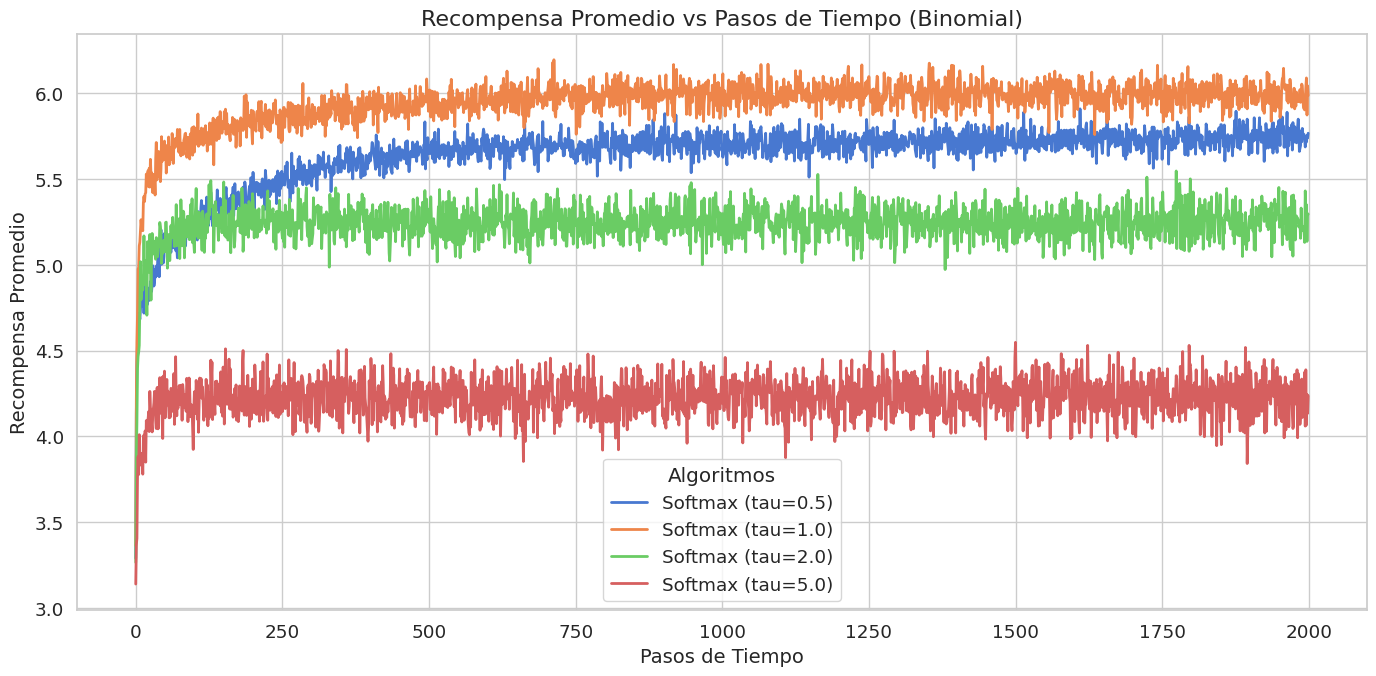

In [7]:
plot_average_rewards(steps, rewards_bi, algorithms_binomial, "Binomial")

La gráfica compara el comportamiento de las distintas configuraciones del algoritmo **Softmax** en el entorno Binomial. En el eje **x** aparecen los **pasos de tiempo**, mientras que en el eje **y** se representa la **recompensa promedio** obtenida por cada política a lo largo del proceso de aprendizaje.

##### **Interpretación de las líneas del gráfico**

Cada una de las cuatro líneas del gráfico se corresponde con una configuración distinta del parámetro de temperatura, y la estrategia que representa según nuestro diseño experimental:

- **Azul ($\tau = 0.5$):** Representa la estrategia más explotadora del conjunto. Con una temperatura baja, las diferencias entre los valores estimados $Q_t(a)$ se amplifican de forma significativa, por lo que el algoritmo tiende a concentrar rápidamente sus selecciones en los brazos con mayor estimación inicial.
- **Naranja ($\tau = 1.0$):** Representa una estrategia moderadamente explotadora. La temperatura es lo suficientemente baja como para dar preferencia clara a las mejores acciones, pero permite cierta exploración que ayuda a corregir estimaciones iniciales erróneas.
- **Verde ($\tau = 2.0$):** Representa una temperatura intermedia que ofrece un mayor equilibrio entre exploración y explotación, distribuyendo las selecciones de forma más amplia entre los brazos.
- **Roja ($\tau = 5.0$):** Representa la estrategia más exploradora. Con una temperatura muy alta, las probabilidades de selección se aproximan a la distribución uniforme $1/k$, lo que implica una exploración casi aleatoria.

##### **Evolución de la recompensa promedio**

El gráfico muestra diferencias muy pronunciadas entre las cuatro configuraciones estudiadas, con una separación clara en diferentes niveles de rendimiento.

La línea naranja ($\tau = 1.0$) es la que mejor rendimiento obtiene con diferencia, estabilizándose en torno a $6.0$ tras una fase de crecimiento rápida en los primeros 200-300 pasos. A continuación, la línea azul ($\tau = 0.5$) alcanza valores cercanos a $5.7$, mostrando también crecimiento inicial pero convergiendo a un nivel notablemente inferior. La línea verde ($\tau = 2.0$) se estabiliza alrededor de $5.3$, con oscilaciones moderadas y persistentes durante todo el experimento. Por último, la línea roja ($\tau = 5.0$) muestra el peor resultado, estabilizándose en torno a $4.25$ prácticamente desde las primeras iteraciones, con las oscilaciones más pronunciadas del conjunto.

El resultado más reseñable es que la configuración con temperatura moderada ($\tau = 1.0$) supera claramente a todas las demás, incluida la más explotadora ($\tau = 0.5$). Esto indica que con $\tau = 0.5$ el algoritmo, aunque no colapsa de forma tan extrema como ocurría con $\tau = 0.1$ en el experimento Normal, sí tiende a quedarse estancado en brazos subóptimos desde las primeras iteraciones, sin explorar lo suficiente como para corregir sus estimaciones iniciales.

Todas las configuraciones presentan oscilaciones apreciables a lo largo de todo el experimento, lo que es coherente con la varianza intrínseca de la distribución Binomial ($\sigma^2 = n \cdot p \cdot (1-p)$), que introduce ruido en cada observación individual y se traslada directamente a la recompensa promedio de cada paso.

Cabe destacar que la mejor configuración ($\tau = 1.0$) se sitúa a menos de un punto por debajo del óptimo teórico del brazo óptimo, lo que representa un rendimiento razonablemente bueno pero aún lejos de la convergencia completa. El resto de configuraciones acumulan diferencias de entre $1$ y $2.5$ puntos, lo que pone de manifiesto la alta sensibilidad del algoritmo al parámetro de temperatura también en este entorno.

#### Porcentaje de selección de la acción óptima

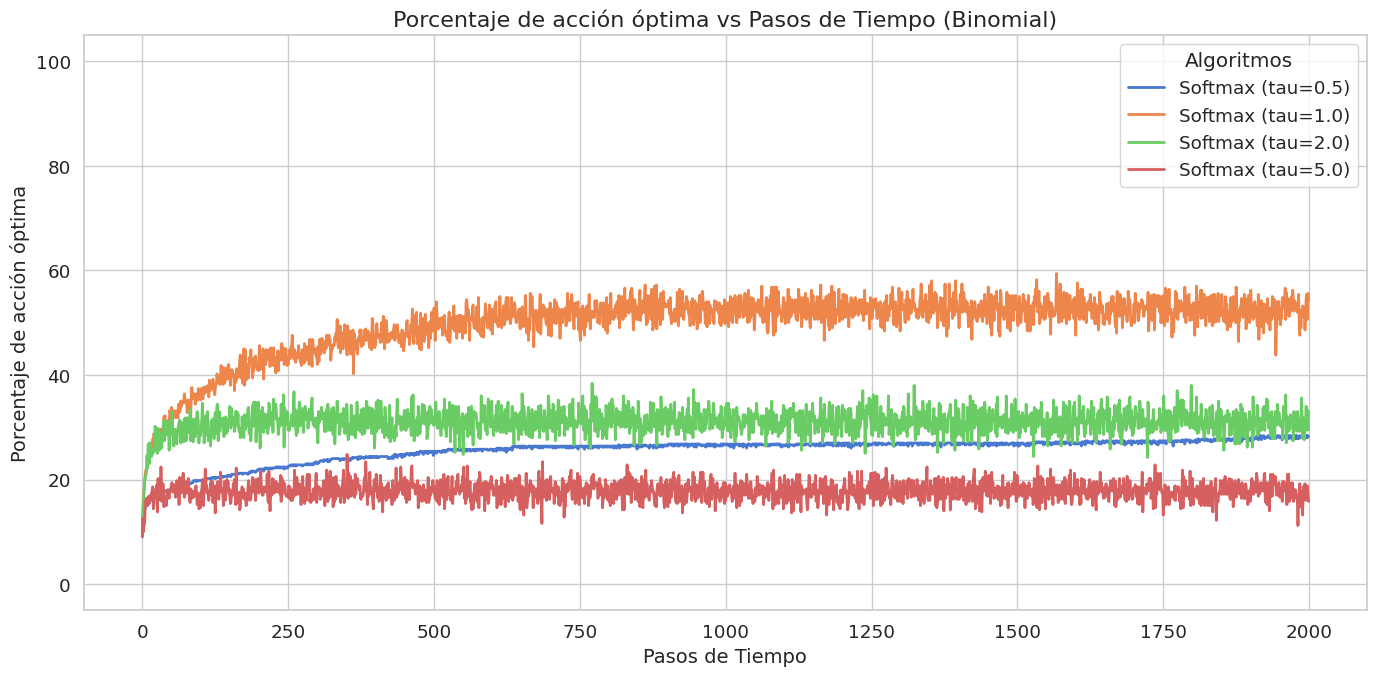

In [8]:
plot_optimal_selections(steps, optimal_bi, algorithms_binomial, "Binomial")

En el eje **x** de la gráfica se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de veces que se selecciona la acción óptima**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**

##### **Evolución del porcentaje de acción óptima**

Los resultados de esta gráfica son llamativos, ya que los porcentajes de selección óptima son notablemente bajos para la mayoría de configuraciones, como es habitual en los experimentos con Softmax de temperatura fija.

La línea naranja ($\tau = 1.0$) es la que mejor rendimiento obtiene con diferencia, mostrando una tendencia de mejora sostenida a lo largo del experimento, creciendo desde aproximadamente el $15\%$ hasta situarse en torno al $53\text{-}56\%$ al final de las 2000 iteraciones. Este valor es el más alto alcanzado en los tres experimentos de Softmax realizados, lo que sugiere que esta configuración logra identificar y explotar de forma relativamente consistente el brazo óptimo en el entorno Binomial.

La línea verde ($\tau = 2.0$) se estabiliza alrededor del $28\text{-}30\%$ con oscilaciones constantes, reflejando la exploración más amplia característica de temperaturas intermedias-altas. La línea azul ($\tau = 0.5$) muestra un comportamiento similar, estabilizándose también en torno al $27\%$, lo que resulta llamativo ya que a pesar de ser la configuración más explotadora, no consigue un porcentaje de selección óptima superior al de $\tau = 2.0$. Esto evidencia que la sobreexplotación temprana con $\tau = 0.5$ lleva al algoritmo a quedar atrapado en brazos subóptimos con frecuencia. Por último, la línea roja ($\tau = 5.0$) se mantiene prácticamente plana en torno al $18\%$ durante todo el experimento, un valor apenas superior al $10\%$ esperado de una política puramente aleatoria con 10 brazos.

Es interesante observar que, a diferencia de la gráfica de recompensa promedio donde las cuatro configuraciones mostraban una separación clara en cuatro niveles ordenados, aquí las líneas azul ($\tau = 0.5$) y verde ($\tau = 2.0$) se solapan considerablemente. Esto indica que $\tau = 0.5$, pese a obtener mayor recompensa promedio que $\tau = 2.0$, no selecciona el brazo óptimo con más frecuencia, sino que concentra sus selecciones en un conjunto reducido de brazos con recompensas altas sin identificar necesariamente el óptimo global.

#### Rechazo acumulado

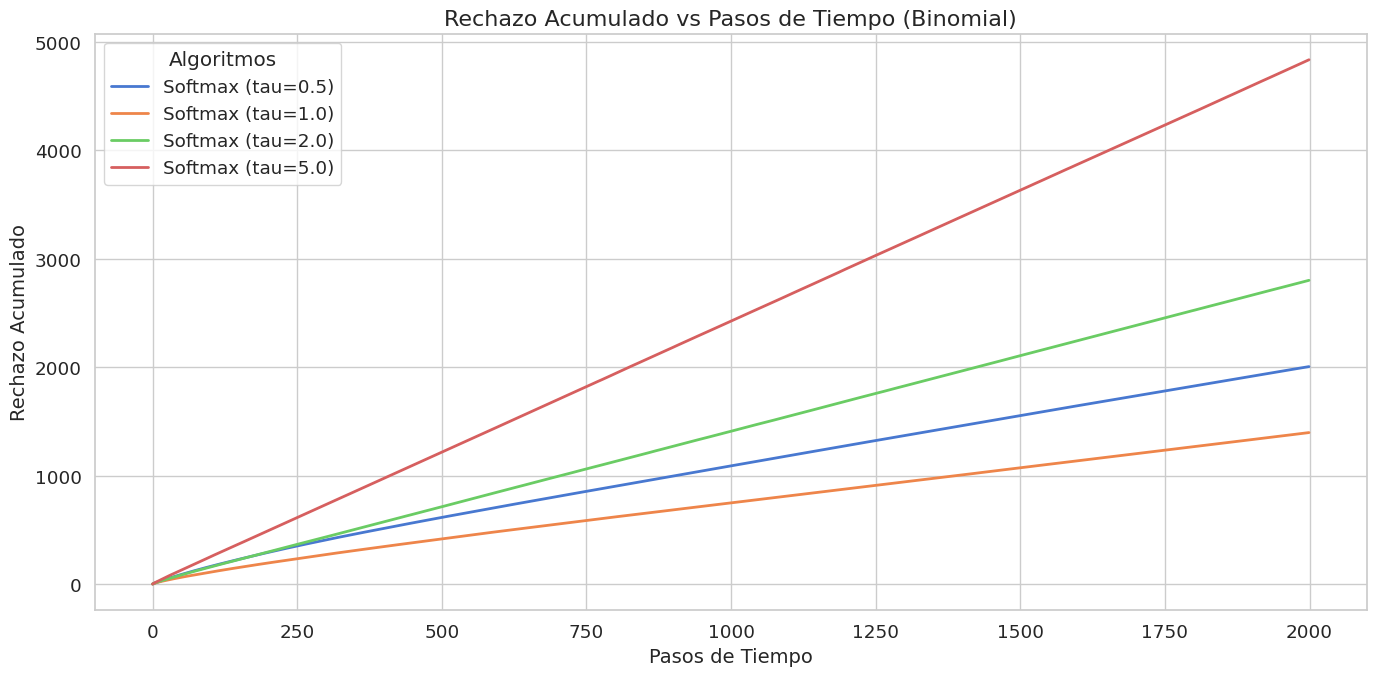

In [9]:
plot_regret(steps, regrets_bi, algorithms_binomial, "Binomial")

En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **rechazo acumulado**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**

##### **Evolución global del rechazo acumulado**

El gráfico del rechazo acumulado muestra diferencias muy pronunciadas entre las configuraciones, con pendientes claramente distintas que se manifiestan desde las primeras iteraciones.

La línea naranja ($\tau = 1.0$) obtiene el mejor resultado ($\approx 1400$ al final del experimento), con un crecimiento que, aunque predominantemente lineal, presenta una ligera tendencia a reducir su pendiente conforme avanza el experimento, lo que sugiere un cierto aprendizaje progresivo. La línea azul ($\tau = 0.5$) alcanza un valor intermedio ($\approx 2050$), mostrando un crecimiento lineal sostenido a lo largo de todo el horizonte. Es destacable que ambas curvas se separan de forma progresiva: durante los primeros 250 pasos presentan valores muy similares, pero a partir de ese punto la configuración $\tau = 1.0$ comienza a beneficiarse de sus mejores estimaciones.

La línea verde ($\tau = 2.0$) alcanza un rechazo de $\approx 2850$, con un crecimiento estrictamente lineal que refleja la incapacidad de la exploración amplia para concentrar selecciones en el brazo óptimo. Por último, la línea roja ($\tau = 5.0$) muestra el peor resultado con diferencia ($\approx 4850$), con la pendiente más pronunciada y un crecimiento estrictamente lineal, coherente con una política que explora de forma casi aleatoria durante toda la ejecución.

En comparación con los otros dos experimentos de Softmax realizados, el comportamiento en el entorno Binomial se sitúa en un punto intermedio: no se observa la tendencia sublineal clara que mostraba la mejor configuración en el entorno Bernoulli, pero tampoco el crecimiento estrictamente lineal uniforme para todas las configuraciones que caracterizaba al entorno Normal. La configuración $\tau = 1.0$ muestra indicios de aprendizaje que, aunque modestos, son más prometedores que los observados en el experimento Normal.

### Ganancia promedio y número de selecciones por brazo

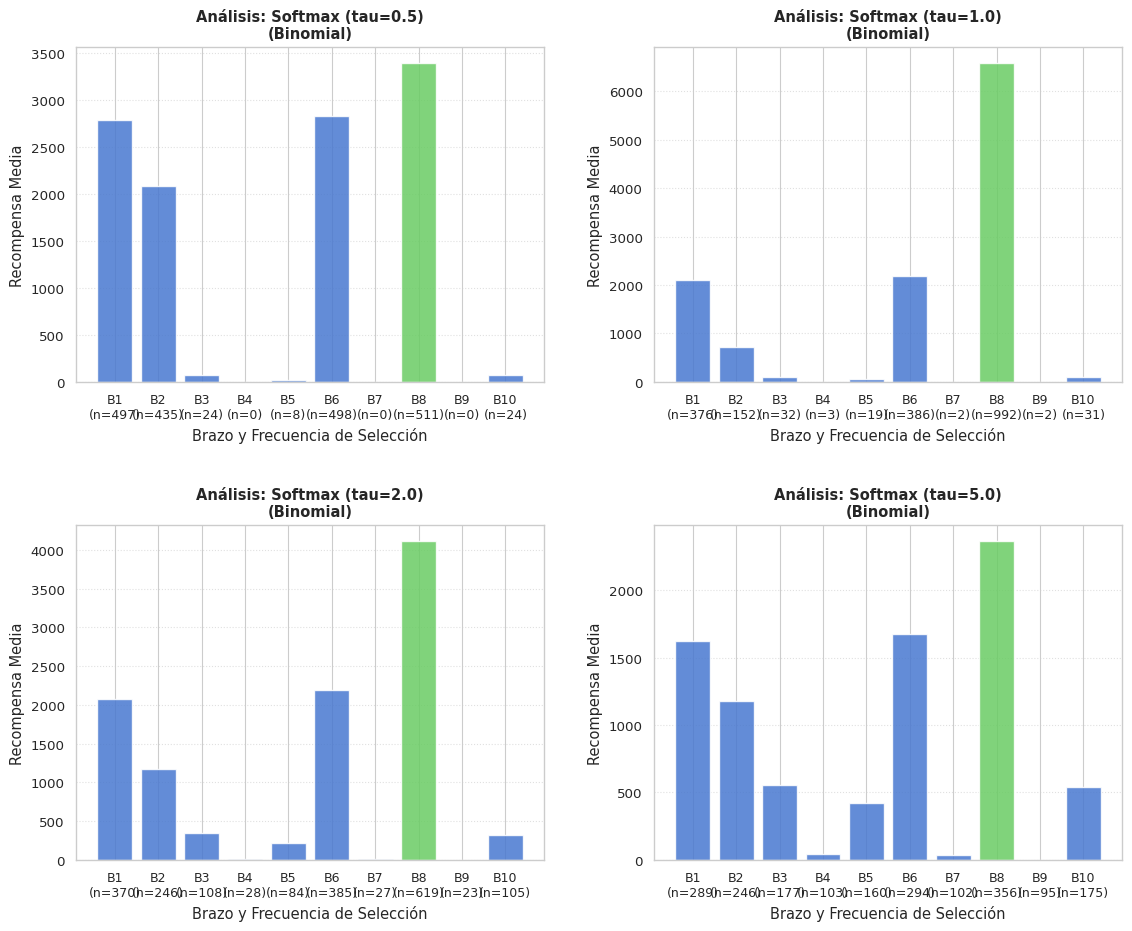

In [10]:
plot_arm_statistics(arm_stats_bi, algorithms_binomial, k, optimal_arm, "Binomial")

La imagen muestra cuatro gráficos de barras, en los que el eje x representa cada uno de los brazos del bandido, indicando entre paréntesis el número medio de selecciones por brazo a lo largo de las 500 ejecuciones, y en el eje y se muestra la ganancia media obtenida de cada brazo. La barra del brazo óptimo (B8) se muestra en verde para diferenciarla del resto.

Las cuatro gráficas reflejan de forma clara todo lo que hemos observado en el análisis de las métricas anteriores. Para $\tau = 1.0$, las selecciones se concentran de forma muy marcada en el brazo óptimo B8 ($n = 992$), que acumula casi la mitad de todas las selecciones, seguido a distancia por B6 ($n = 386$) y B1 ($n = 376$), mientras que los demás brazos reciben un número residual de selecciones. Esta concentración es coherente con el mejor rendimiento global que esta configuración mostró en todas las métricas.

Para $\tau = 0.5$, la distribución es más repartida de lo que cabría esperar para la configuración más explotadora: B8 recibe $n = 511$ selecciones, pero B6 ($n = 498$), B1 ($n = 497$) y B2 ($n = 435$) acumulan un número comparable, lo que explica por qué esta configuración obtenía una recompensa promedio alta pero un porcentaje de selección óptima relativamente bajo. El algoritmo explota eficazmente un subconjunto de brazos buenos, pero no logra discriminar el óptimo global del resto del grupo de cabeza.

Para $\tau = 2.0$, el brazo óptimo B8 sigue siendo el más seleccionado ($n = 619$), pero la distribución se extiende de forma más uniforme hacia el resto de brazos, incluyendo los de menor recompensa como B5 ($n = 84$) y B4 ($n = 28$). Finalmente, $\tau = 5.0$ presenta la distribución más uniforme de todas, con selecciones repartidas entre todos los brazos de forma casi homogénea, lo que confirma el comportamiento de exploración prácticamente aleatoria observado en las métricas anteriores.

Es importante tener en cuenta que estas gráficas agregan el comportamiento a lo largo de todas las ejecuciones y todos los pasos de tiempo. Por ello, una distribución de selecciones repartida entre varios brazos no implica que el algoritmo haya explorado de forma inteligente, sino que en distintas ejecuciones ha quedado atrapado en distintos subóptimos. Este matiz es especialmente relevante para $\tau = 0.5$, donde la distribución entre B1, B2, B6 y B8 no refleja exploración deliberada, sino que en distintas ejecuciones el algoritmo ha quedado bloqueado en diferentes brazos del grupo de cabeza.

Estos resultados son coherentes con la intuición teórica sobre el comportamiento del algoritmo que habíamos propuesto en el diseño del experimento.

## Conclusiones

El resultado más destacable del experimento es que el algoritmo Softmax con $\tau$ fijo muestra un rendimiento intermedio en el entorno Binomial respecto a los observados en los otros dos experimentos de Softmax realizados. Mientras que en el entorno Normal ninguna configuración superaba el $45\%$ de selecciones óptimas, y en el entorno Bernoulli la mejor configuración alcanzaba el $50\%$, en el entorno Binomial la configuración $\tau = 1.0$ logra el porcentaje más alto de los tres experimentos, situándose en torno al $53\text{-}56\%$.

La configuración $\tau = 1.0$ es la que mejor se comporta en este entorno concreto, logrando la mayor recompensa promedio ($\approx 6.0$), el mayor porcentaje de selecciones óptimas y el menor rechazo acumulado ($\approx 1400$). Este resultado refuerza la observación de que la elección de $\tau$ debe estar calibrada respecto a la escala de las recompensas: en el entorno Binomial con $n = 10$, las recompensas esperadas se sitúan en un rango comparable al del entorno Normal, por lo que los valores de $\tau$ adecuados son también similares. De hecho, $\tau = 1.0$ es la configuración óptima tanto en el entorno Normal como en el Binomial, lo que sugiere que esta temperatura constituye una referencia natural cuando las diferencias entre brazos son del orden de unas pocas unidades.

Los casos extremos ilustran claramente el compromiso exploración-explotación asociado al parámetro de temperatura. La configuración $\tau = 0.5$, aunque es la más explotadora, obtiene un porcentaje de selección óptima similar al de $\tau = 2.0$ ($\approx 27\text{-}30\%$), lo que demuestra que la sobreexplotación temprana no se traduce necesariamente en una mejor identificación del brazo óptimo. La varianza intrínseca de la distribución Binomial hace que las estimaciones iniciales sean ruidosas, de modo que explotar prematuramente puede llevar a quedarse estancado en un brazo subóptimo. En el extremo opuesto, $\tau = 5.0$ no consigue aprovechar la información acumulada y se comporta como una política casi aleatoria durante toda la ejecución.

En comparación con los otros algoritmos estudiados en el proyecto ($\varepsilon$-greedy y UCB), el rendimiento del Softmax con $\tau$ fijo sigue siendo inferior. Nuestra hipótesis es que la limitación principal reside en la naturaleza estática del parámetro $\tau$: una temperatura fija obliga al algoritmo a mantener indefinidamente un nivel constante de exploración o explotación, impidiéndole adaptarse a medida que sus estimaciones mejoran.

Pese a estas limitaciones, el experimento nos ha permitido verificar empíricamente cómo distintos niveles de temperatura producen regímenes cualitativamente distintos en el entorno Binomial, confirmar que la calibración de $\tau$ respecto a la escala del entorno es un factor determinante del rendimiento, y constatar que el algoritmo Softmax con temperatura fija tiene dificultades estructurales para converger al brazo óptimo de forma consistente, independientemente de la distribución de recompensas utilizada.